Some imports:

In [1]:
using CairoMakie
using Distributions
using Enzyme
using LaTeXStrings
using PairPlots
using Random
using StatsFuns
using TruncatedPopulations
using Turing


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Set up some parameters:

In [2]:
N = 100

mu_true = 1.0
sigma_true = 0.15

sigma_obs = 0.25

Nmcmc = 1000
Ntune = Nmcmc
target_accept = 0.8

0.8

Draw some samples from the population (seed for reproducability):

In [3]:
Random.seed!(0x3fe0633ad296b0de)
qs_true = draw_truncated_population(mu_true, sigma_true, N);

This is what they look like:

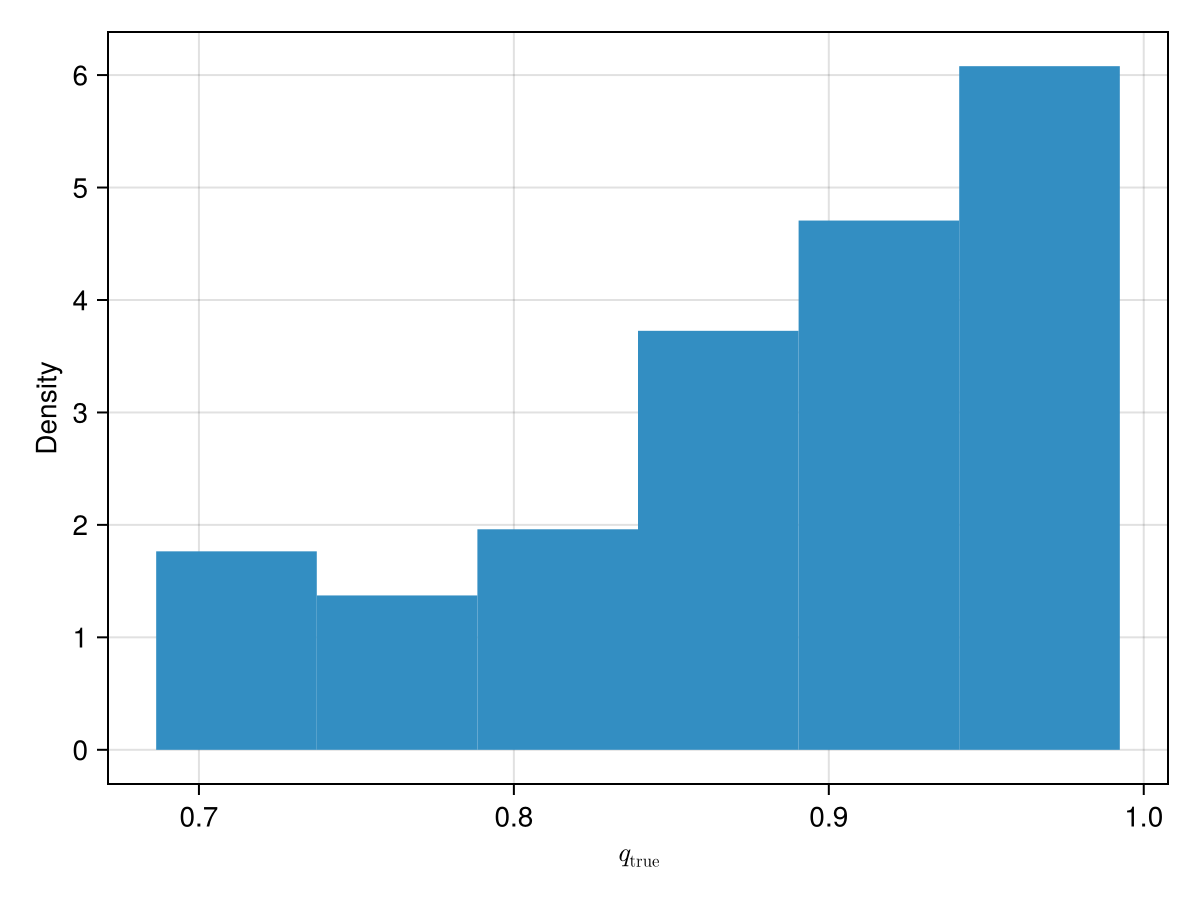

In [4]:
f = Figure()
a = Axis(f[1,1], xlabel=L"q_\mathrm{true}", ylabel="Density")
hist!(a, qs_true, normalization=:pdf, bins=scotts_rule_bins(qs_true))
f

Generate mock observations of these samples (observational noise is additive Gaussian, with a width a bit more than the population width):

In [5]:
Random.seed!(0x72d690d80b9f37d8)
qs_obs = draw_observed_population(qs_true, sigma_obs);

Here are the observed $q$:

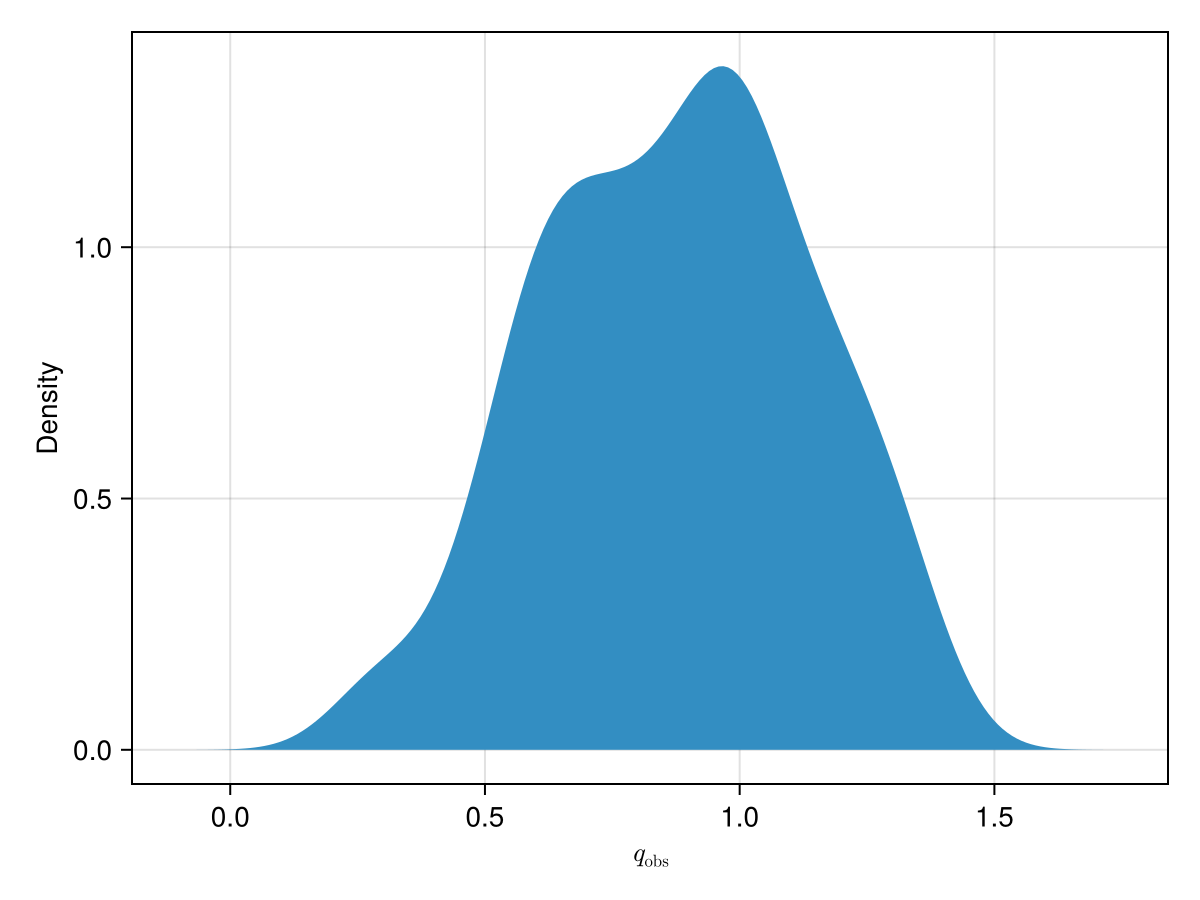

In [6]:
f = Figure()
a = Axis(f[1,1], xlabel=L"q_\mathrm{obs}", ylabel="Density")
density!(a, qs_obs)
f

Now let's sample from the exact likelihood model; we will use the Enzyme reverse AD backend because (1) it is very efficient and (2) the number of parameters in the model is very large, so reverse AD is needed.

In [7]:
exact_trace = sample(exact_likelihood_model(qs_obs, sigma_obs), NUTS(Ntune, target_accept; adtype=AutoEnzyme(mode=Enzyme.set_runtime_activity(Enzyme.Reverse))), Nmcmc)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference /Users/wfarr/.julia/packages/Turing/H4T0b/src/mcmc/hmc.jl:226
Sampling   0%|▎                                         |  ETA: 1:40:25
Sampling   1%|▍                                         |  ETA: 0:50:09
Sampling   2%|▋                                         |  ETA: 0:33:20
Sampling   2%|▉                                         |  ETA: 0:24:57
Sampling   2%|█                                         |  ETA: 0:19:54
Sampling   3%|█▎                                        |  ETA: 0:16:32
Sampling   4%|█▌                                        |  ETA: 0:14:07
Sampling   4%|█▋                                        |  ETA: 0:12:19
Sampling   4%|█▉                                        |  ETA: 0:10:56
Sampling   5%|██▏                                       |  ETA: 0:09:49
Sampling   6%|██▎                                       |  ETA: 0:08:54
Sampling   6%

Chains MCMC chain (1000×216×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 36.42 seconds
Compute duration  = 36.42 seconds
parameters        = mu, sigma, qs_raw[1], qs_raw[2], qs_raw[3], qs_raw[4], qs_raw[5], qs_raw[6], qs_raw[7], qs_raw[8], qs_raw[9], qs_raw[10], qs_raw[11], qs_raw[12], qs_raw[13], qs_raw[14], qs_raw[15], qs_raw[16], qs_raw[17], qs_raw[18], qs_raw[19], qs_raw[20], qs_raw[21], qs_raw[22], qs_raw[23], qs_raw[24], qs_raw[25], qs_raw[26], qs_raw[27], qs_raw[28], qs_raw[29], qs_raw[30], qs_raw[31], qs_raw[32], qs_raw[33], qs_raw[34], qs_raw[35], qs_raw[36], qs_raw[37], qs_raw[38], qs_raw[39], qs_raw[40], qs_raw[41], qs_raw[42], qs_raw[43], qs_raw[44], qs_raw[45], qs_raw[46], qs_raw[47], qs_raw[48], qs_raw[49], qs_raw[50], qs_raw[51], qs_raw[52], qs_raw[53], qs_raw[54], qs_raw[55], qs_raw[56], qs_raw[57], qs_raw[58], qs_raw[59], qs_raw[60], qs_raw[61], qs_raw[62], qs_raw[63], qs_raw[64], qs_raw[65], 

The sampling is sorta shit (1000 samples, but only ~100s effective sample size), but not so terrible that it's not worth looking at the result:

In [8]:
describe(exact_trace)

Chains MCMC chain (1000×216×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 36.42 seconds
Compute duration  = 36.42 seconds
parameters        = mu, sigma, qs_raw[1], qs_raw[2], qs_raw[3], qs_raw[4], qs_raw[5], qs_raw[6], qs_raw[7], qs_raw[8], qs_raw[9], qs_raw[10], qs_raw[11], qs_raw[12], qs_raw[13], qs_raw[14], qs_raw[15], qs_raw[16], qs_raw[17], qs_raw[18], qs_raw[19], qs_raw[20], qs_raw[21], qs_raw[22], qs_raw[23], qs_raw[24], qs_raw[25], qs_raw[26], qs_raw[27], qs_raw[28], qs_raw[29], qs_raw[30], qs_raw[31], qs_raw[32], qs_raw[33], qs_raw[34], qs_raw[35], qs_raw[36], qs_raw[37], qs_raw[38], qs_raw[39], qs_raw[40], qs_raw[41], qs_raw[42], qs_raw[43], qs_raw[44], qs_raw[45], qs_raw[46], qs_raw[47], qs_raw[48], qs_raw[49], qs_raw[50], qs_raw[51], qs_raw[52], qs_raw[53], qs_raw[54], qs_raw[55], qs_raw[56], qs_raw[57], qs_raw[58], qs_raw[59], qs_raw[60], qs_raw[61], qs_raw[62], qs_raw[63], qs_raw[64], qs_raw[65], 

We get a reasonable (or at least *consistent*) estimate of the population parameters:

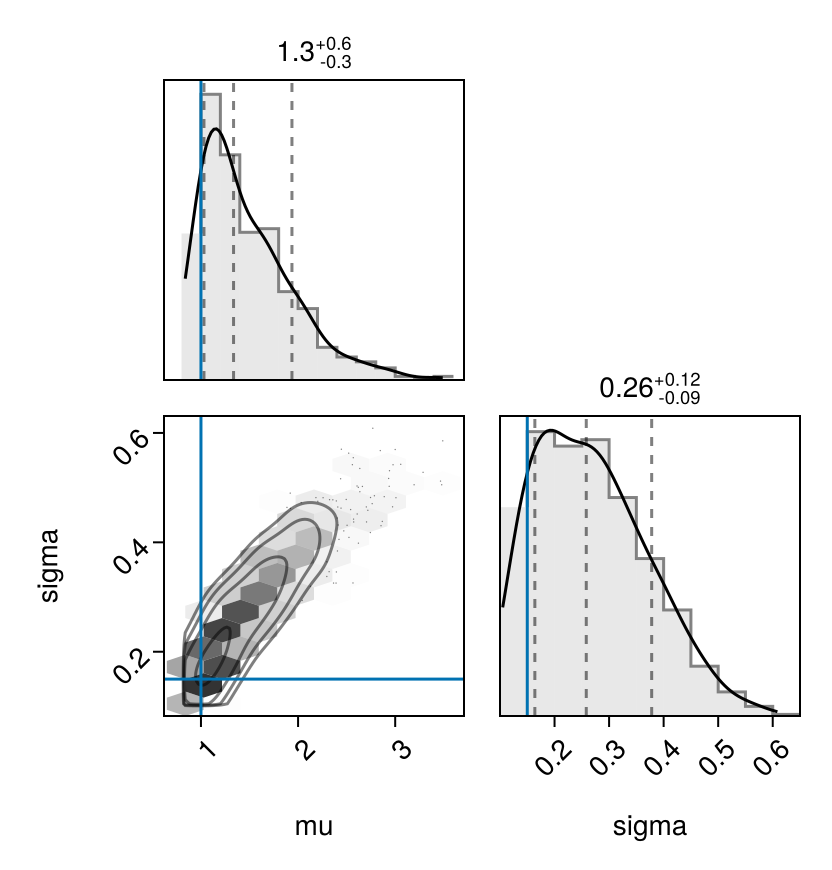

In [9]:
pairplot(exact_trace[[:mu, :sigma]], PairPlots.Truth((; mu = mu_true, sigma = sigma_true)))

Just to check, here are some random components of $q$ that are measured by the model as well:

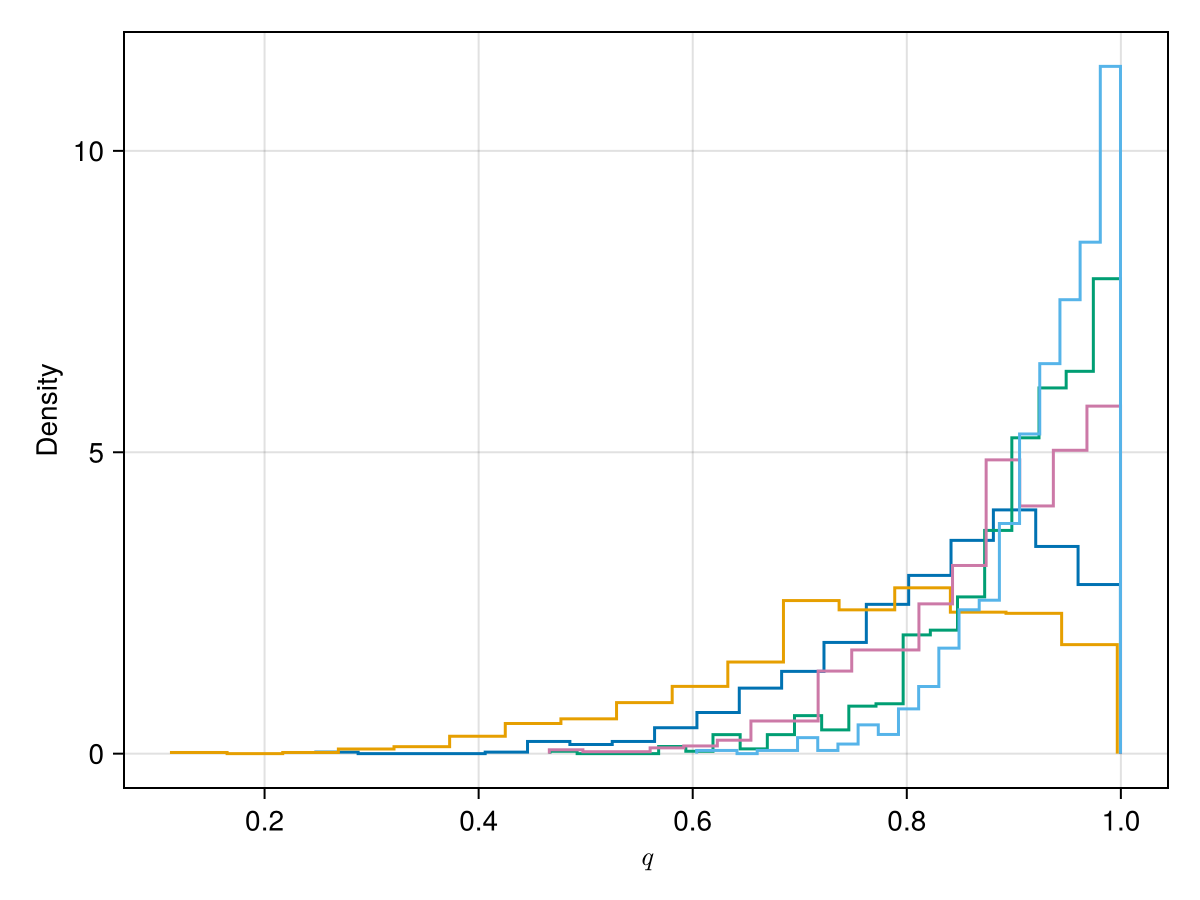

In [10]:
f = Figure()
a = Axis(f[1,1], xlabel=L"q", ylabel="Density")

for _ in 1:5
    i = rand(1:length(qs_obs))
    x = vec(exact_trace["qs[$i]"])
    stephist!(a, x, normalization=:pdf, bins=scotts_rule_bins(x))
end

f

Let's draw 1k samples per observation, and then have a look at the resulting sampling:

In [11]:
Random.seed!(0xec0a982e813273f7)
q_samples = draw_likelihood_samples(qs_obs, sigma_obs);

Let's sample from this using the "samples model," that uses the samples to Monte-Carlo integrate the likelihood.

In [12]:
samples_trace = sample(samples_model(q_samples), NUTS(Ntune, target_accept; adtype=AutoEnzyme(mode=Enzyme.set_runtime_activity(Enzyme.Reverse))), Nmcmc)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 1.3109375
└ @ Turing.Inference /Users/wfarr/.julia/packages/Turing/H4T0b/src/mcmc/hmc.jl:226
Sampling   0%|▎                                         |  ETA: 0:45:49
Sampling   1%|▍                                         |  ETA: 0:24:51
Sampling   2%|▋                                         |  ETA: 0:18:10
Sampling   2%|▉                                         |  ETA: 0:14:25
Sampling   2%|█                                         |  ETA: 0:12:17
Sampling   3%|█▎                                        |  ETA: 0:10:26
Sampling   4%|█▌                                        |  ETA: 0:09:07
Sampling   4%|█▋                                        |  ETA: 0:08:09
Sampling   4%|█▉                                        |  ETA: 0:07:43
Sampling   5%|██▏                                       |  ETA: 0:07:06
Sampling   6%|██▎                                       |  ETA: 0:06:41
Samplin

Chains MCMC chain (1000×116×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 126.06 seconds
Compute duration  = 126.06 seconds
parameters        = mu, sigma, neff[1], neff[2], neff[3], neff[4], neff[5], neff[6], neff[7], neff[8], neff[9], neff[10], neff[11], neff[12], neff[13], neff[14], neff[15], neff[16], neff[17], neff[18], neff[19], neff[20], neff[21], neff[22], neff[23], neff[24], neff[25], neff[26], neff[27], neff[28], neff[29], neff[30], neff[31], neff[32], neff[33], neff[34], neff[35], neff[36], neff[37], neff[38], neff[39], neff[40], neff[41], neff[42], neff[43], neff[44], neff[45], neff[46], neff[47], neff[48], neff[49], neff[50], neff[51], neff[52], neff[53], neff[54], neff[55], neff[56], neff[57], neff[58], neff[59], neff[60], neff[61], neff[62], neff[63], neff[64], neff[65], neff[66], neff[67], neff[68], neff[69], neff[70], neff[71], neff[72], neff[73], neff[74], neff[75], neff[76], neff[77], neff[78]

Sampling here is also shit, and the minimum number of effective samples per event is pretty small; nevertheless, let's proceed (it will turn out to give consistent inferences, so good enough)?

In [13]:
describe(samples_trace)

Chains MCMC chain (1000×116×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 126.06 seconds
Compute duration  = 126.06 seconds
parameters        = mu, sigma, neff[1], neff[2], neff[3], neff[4], neff[5], neff[6], neff[7], neff[8], neff[9], neff[10], neff[11], neff[12], neff[13], neff[14], neff[15], neff[16], neff[17], neff[18], neff[19], neff[20], neff[21], neff[22], neff[23], neff[24], neff[25], neff[26], neff[27], neff[28], neff[29], neff[30], neff[31], neff[32], neff[33], neff[34], neff[35], neff[36], neff[37], neff[38], neff[39], neff[40], neff[41], neff[42], neff[43], neff[44], neff[45], neff[46], neff[47], neff[48], neff[49], neff[50], neff[51], neff[52], neff[53], neff[54], neff[55], neff[56], neff[57], neff[58], neff[59], neff[60], neff[61], neff[62], neff[63], neff[64], neff[65], neff[66], neff[67], neff[68], neff[69], neff[70], neff[71], neff[72], neff[73], neff[74], neff[75], neff[76], neff[77], neff[78]

This is not super large, but should be enough to be safe:

In [14]:
min_neff = Inf
for i in 1:N
    min_ne = minimum(samples_trace["neff[$i]"])
    min_neff = min(min_neff, min_ne)
end
println("Minimum neff: $(round(min_neff, digits=2))")

Minimum neff: 8.27


Here is the result using the Monte-Carlo integrals compared to the exact likelihood; looks identical to me?

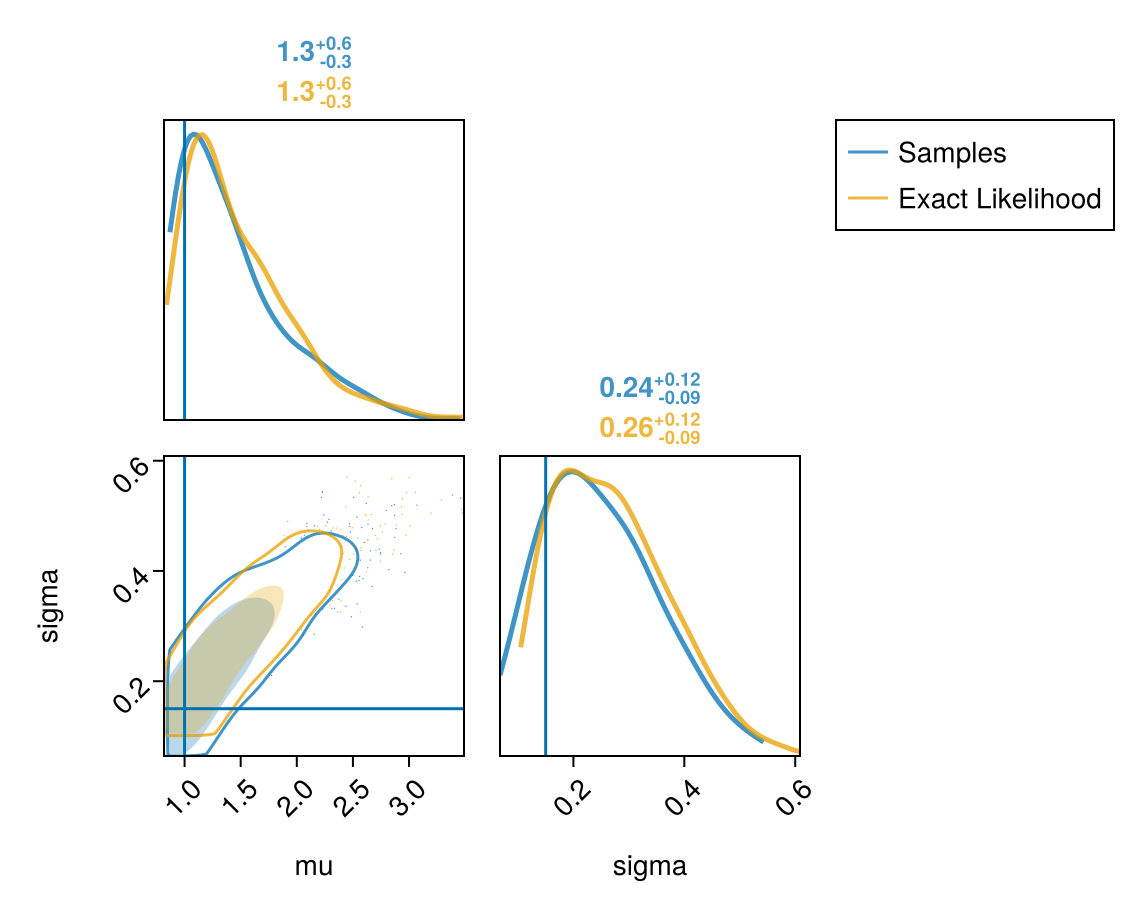

In [15]:
csamples = Makie.wong_colors(0.75)[1]
cexact = Makie.wong_colors(0.75)[2]
pairplot(PairPlots.Series(samples_trace[[:mu, :sigma]], label="Samples", color=csamples, strokecolor=csamples), PairPlots.Series(exact_trace[[:mu, :sigma]], label="Exact Likelihood", color=cexact, strokecolor=cexact), PairPlots.Truth((; mu = mu_true, sigma = sigma_true)))